In [18]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import re


In [19]:
with open("../data/CUADv1.json") as f:
    data = json.load(f)

test = pd.DataFrame.from_records(data)

test.info()


<class 'pandas.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   data     510 non-null    object
 1   version  510 non-null    str   
dtypes: object(1), str(1)
memory usage: 8.1+ KB


In [20]:
test.describe()


,data,version
count,510,510
unique,510,1
top,{'title': 'LIMEENERGYCO_09_09_1999-EX-10-DISTR...,aok_v1.0
freq,1,510


In [21]:
rows = []
for contract in data["data"]:
    title = contract["title"]
    for qa in contract["paragraphs"][0]["qas"]:
        if qa["is_impossible"]:
            continue
        category = qa["question"].split('"')[1]
        for answer in qa["answers"]:
            rows.append({"contract": title, "category": category, "clause_text": answer["text"].strip()})

df = pd.DataFrame(rows)
df.head()



,contract,category,clause_text
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,DISTRIBUTOR AGREEMENT
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Distributor
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Electric City Corp.
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Electric City of Illinois L.L.C.
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Company


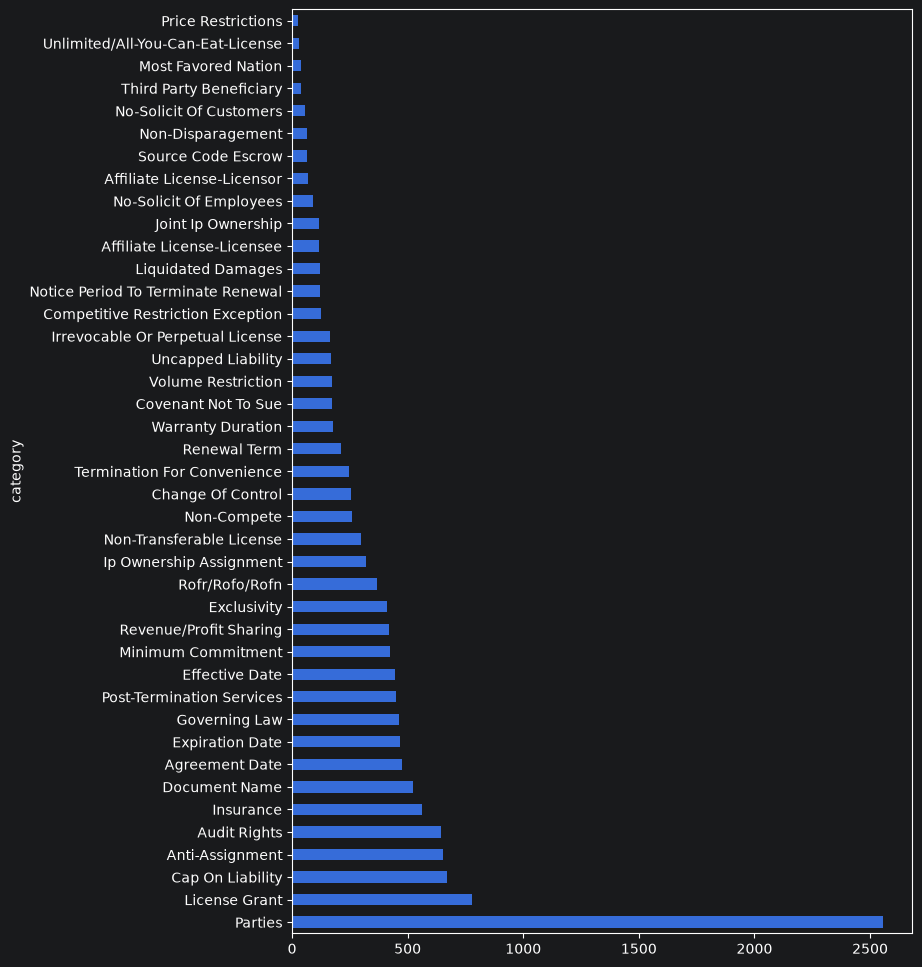

In [22]:


df["category"].value_counts().plot(kind="barh", figsize=(8, 12))
plt.show()

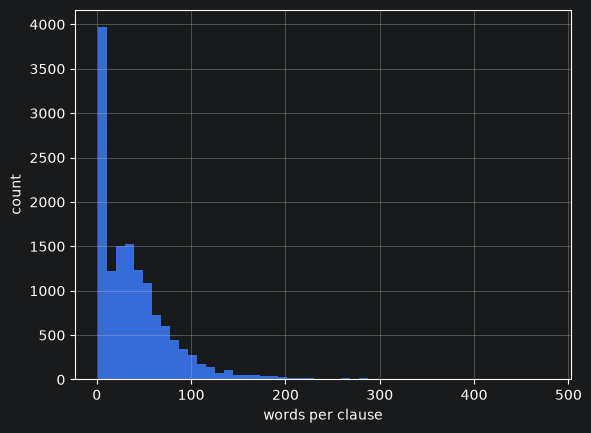

In [23]:
df["word_count"] = df["clause_text"].str.split().str.len()
df["word_count"].hist(bins=50)
category_words = df.groupby("category")["word_count"].agg(["count"])
category_words.head(20)
plt.xlabel("words per clause")
plt.ylabel("count")
plt.show()

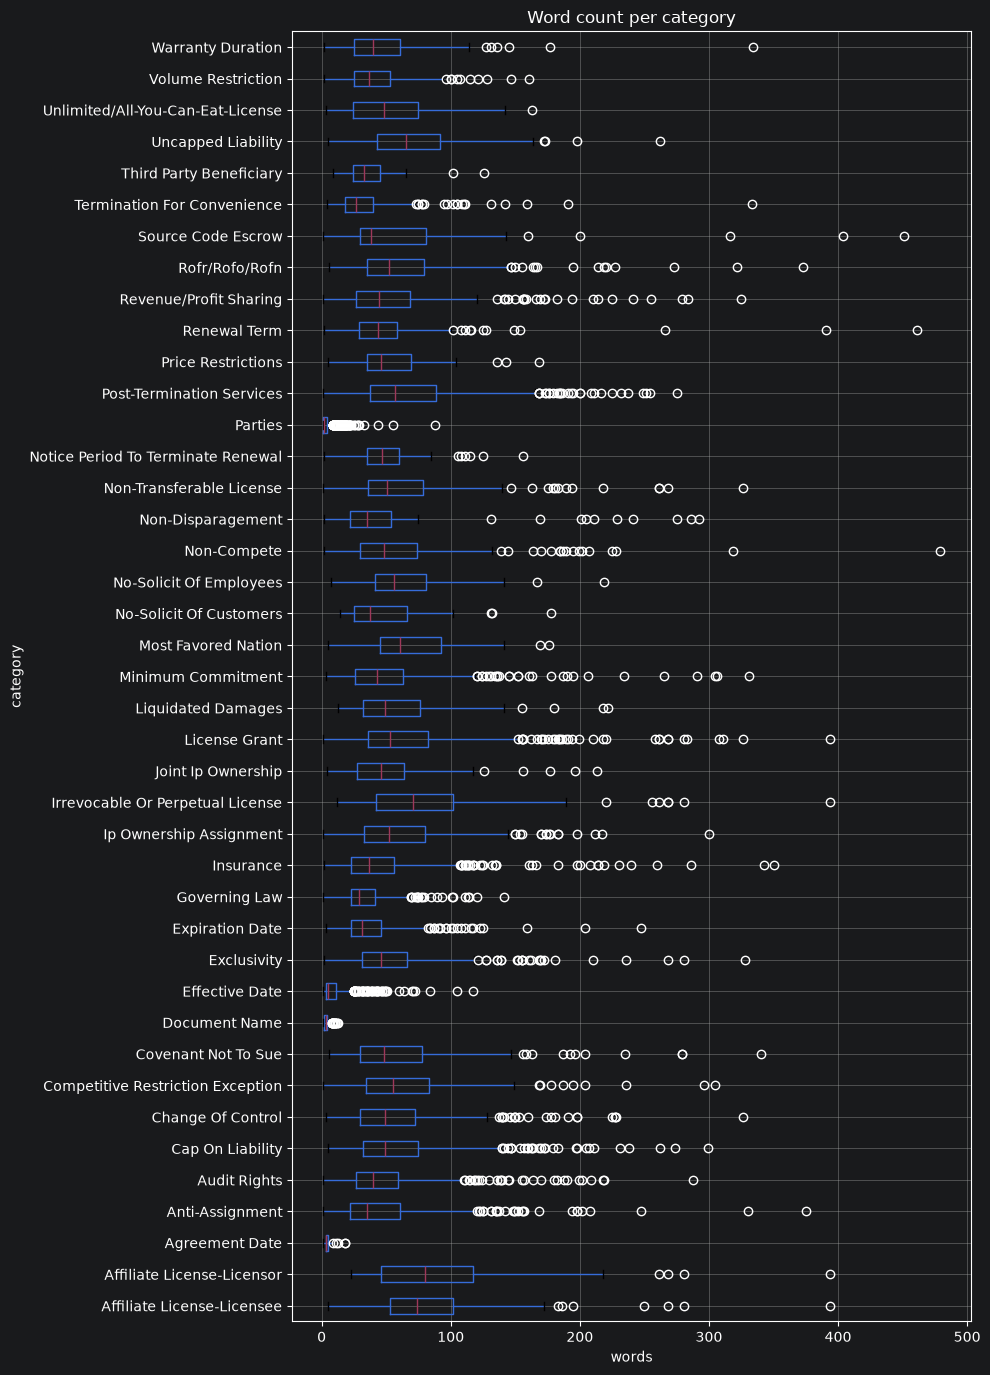

In [24]:
# make sure word_count exists
df["word_count"] = df["clause_text"].str.split().str.len()

# summary table: count, median, min, max per category
category_stats = df.groupby("category")["word_count"].agg(["count", "median", "min", "max"]).sort_values("median")
category_stats

df.boxplot(column="word_count", by="category", vert=False, figsize=(10, 14))
plt.suptitle("")
plt.title("Word count per category")
plt.xlabel("words")
plt.tight_layout()
plt.show()

In [25]:
FACT_ONLY = ["Parties", "Document Name", "Agreement Date", "Effective Date"]
df_filtered = df[~df["category"].isin(FACT_ONLY)]

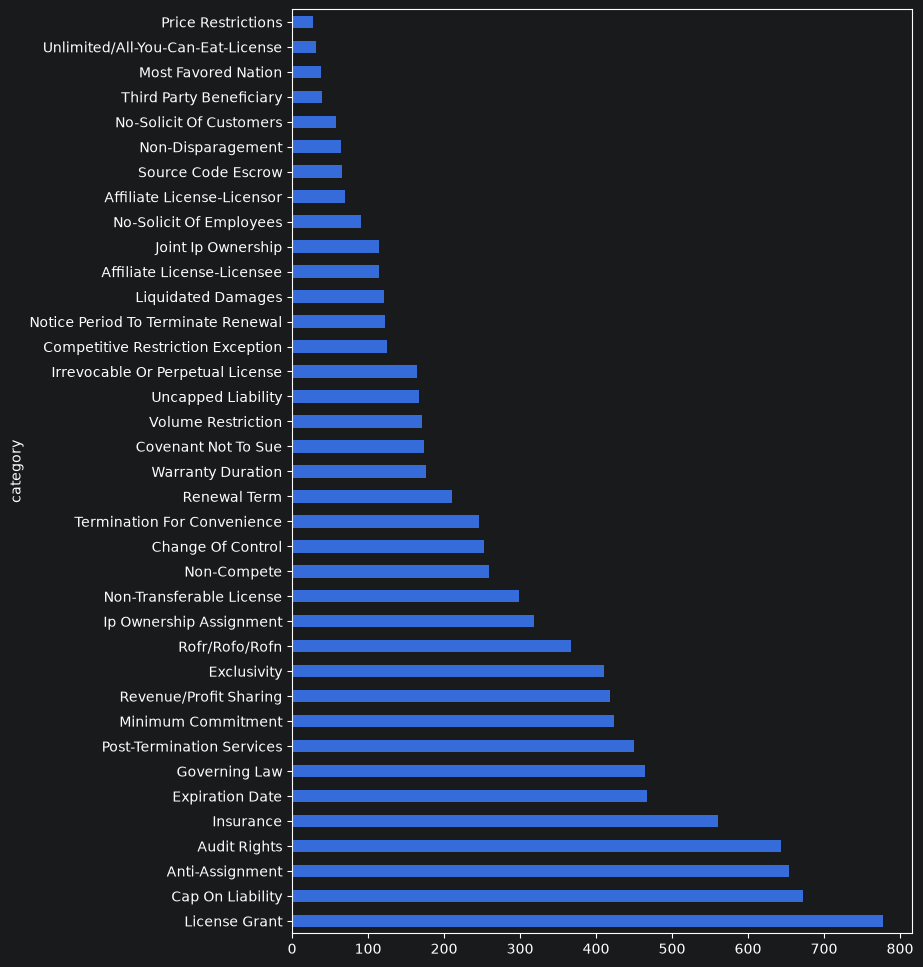

In [26]:
df_filtered["category"].value_counts().plot(kind="barh", figsize=(8, 12))
plt.show()

In [27]:
df_filtered.sort_values("word_count")
df_filtered["clause_text"].str.contains(r"\[\*+\]", regex=True, na=False).sum()


np.int64(611)

In [52]:
df_filtered.sort_values("word_count")
df_wordcount8 =df_filtered[df_filtered["word_count"] >= 8]
df_wordcount8.sort_values("word_count").head(30)




,contract,category,clause_text,word_count
1265,CreditcardscomInc_20070810_S-1_EX-10.33_362297...,Termination For Convenience,Chase may revoke Affiliate's license at any time.,8
1582,WORLDWIDESTRATEGIESINC_11_02_2005-EX-10-RESELL...,Covenant Not To Sue,"In particular, and without limitation, Reselle...",8
3423,TcPipelinesLp_20160226_10-K_EX-99.12_9454048_E...,Expiration Date,"TERM: November 01, 2014 to October 31, 2017",8
4147,EcoScienceSolutionsInc_20171117_8-K_EX-10.1_10...,Non-Transferable License,Such usage may not be sold or transferred.,8
8376,EhaveInc_20190515_20-F_EX-4.44_11678816_EX-4.4...,Audit Rights,No period shall be audited more than once.,8
8701,HealthcentralCom_19991108_S-1A_EX-10.27_662329...,Non-Transferable License,During the Term of this Agreement MLX shall:,8
12975,IbioInc_20200313_8-K_EX-10.1_12052678_EX-10.1_...,Anti-Assignment,Any unauthorized assignment of this Agreement ...,8
7845,KALLOINC_11_03_2011-EX-10.1-STRATEGIC ALLIANCE...,Exclusivity,"Exclusivity is granted for the region of Nigeria,",8
11091,EmbarkComInc_19991008_S-1A_EX-10.10_6487661_EX...,License Grant,Sponsor Content in and on the Co-Branded Pages.,8
9465,"FIDELITYNATIONALINFORMATIONSERVICES,INC_08_05_...",Joint Ip Ownership,"As of the Closing Date, all right, title",8


rows: 9699
raw [***] remaining: 0
[REDACTED AMOUNT]: 253
[REDACTED DURATION]: 84
[REDACTED] (generic): 150


In [82]:

AMOUNT_CATEGORIES = {
    "Minimum Commitment", "Revenue/Profit Sharing", "Cap On Liability",
    "Liquidated Damages", "Price Restrictions", "Volume Restriction", "Insurance",
}
DURATION_CATEGORIES = {
    "Post-Termination Services", "Warranty Duration",
    "Renewal Term", "Notice Period To Terminate Renewal",
}
REST_CATEGORIES = REST_CATEGORIES = set(df_clean["category"].unique()) - AMOUNT_CATEGORIES - DURATION_CATEGORIES

mask1 = df_clean["category"].isin(AMOUNT_CATEGORIES)
mask2 = df_clean["category"].isin(DURATION_CATEGORIES)
mask3 = df_clean["category"].isin(REST_CATEGORIES)

df_clean.loc[mask1, "clause_text"] = (
    df_clean.loc[mask1, "clause_text"]
    .str.replace(r"\[\*+\]", "[REDACTED AMOUNT]", regex=True)
)
df_clean.loc[mask2, "clause_text"] = (
    df_clean.loc[mask2, "clause_text"]
    .str.replace(r"\[\*+\]", "[REDACTED DURATION]", regex=True)
)
df_clean.loc[mask3, "clause_text"] = (
    df_clean.loc[mask3, "clause_text"]
    .str.replace(r"\[\*+\]", "[REDACTED]", regex=True)
)
print(mask1.sum(), mask2.sum(), mask3.sum())
print(df_clean["clause_text"].str.contains("[REDACTED", regex=False).sum())
print(df_clean["clause_text"].str.contains(r"\[\*+\]", regex=True, na=False).sum())
len(df_clean)

2363 942 6394
607
0


9699